In [ ]:
import requests
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = requests.get(URL)
boston_url = io.BytesIO(resp.content)

In [ ]:
import pandas as pd

boston_url.seek(0)
df = pd.read_csv(boston_url)
display(df.head(6))

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2
5,5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,5.21,28.7


### Analysis of Scatter Plot (RM vs. MEDV)
This scatter plot shows the relationship between the average number of rooms per dwelling (RM) and the median value of owner-occupied homes (MEDV). There appears to be a positive linear relationship, indicating that as the average number of rooms increases, the median home value tends to increase. However, there are some data points, particularly at higher MEDV values, where the relationship might become less linear or show some outliers.

### Interpretation of Histogram (MEDV)
This histogram displays the distribution of the Median Home Value (MEDV). The distribution appears to be somewhat right-skewed, with a concentration of homes around the lower-to-mid range of values. There's also a noticeable peak or bin at the highest value (50), which might indicate a ceiling effect or truncation in the data for very expensive homes.

### Analysis of Box Plot (AGE)
This box plot for the 'AGE' variable shows the distribution of the proportion of owner-occupied units built prior to 1940. The box represents the interquartile range (IQR), with the line inside indicating the median. The whiskers extend to 1.5 times the IQR from the box. The plot suggests that there's a wide range of ages in the housing stock, with a significant number of older properties (higher AGE values). There do not appear to be significant outliers below the lower whisker, but the upper whisker is quite extended, indicating a large spread towards older properties.

### Analysis of Box Plot (MEDV vs. Age Group)
This box plot illustrates the relationship between the Median Home Value (MEDV) and different age groups of owner-occupied units. It appears that homes in the '35 and younger' age group tend to have higher median values and a wider spread, suggesting more variability in price. Homes in the '70 and older' category seem to have lower median values on average, though there might be outliers in all groups. This visual suggests that newer homes (or areas with newer homes) are generally more valuable.

### Evaluation of Bar Plot (Mean MEDV by CHAS)
This bar plot compares the mean median home value (MEDV) for tracts that bound the Charles River (CHAS=1) versus those that do not (CHAS=0). The plot clearly indicates that tracts bounding the Charles River (CHAS=1) have a significantly higher mean median home value compared to those that do not. This suggests that proximity to the Charles River is a positive factor influencing property values in this dataset.

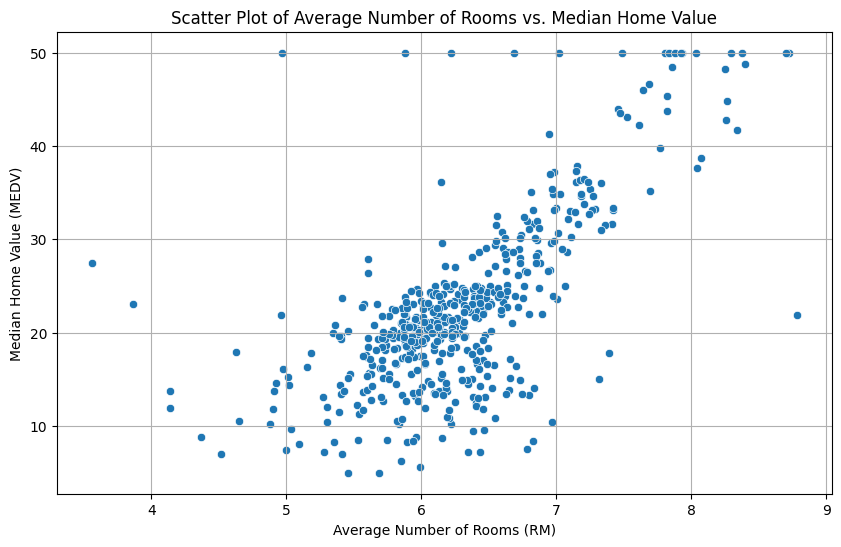

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Question 8: Analyze the given scatter plot.
# Creating a scatter plot of 'RM' (average number of rooms) vs. 'MEDV' (Median value of owner-occupied homes)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='RM', y='MEDV', data=df)
plt.title('Scatter Plot of Average Number of Rooms vs. Median Home Value')
plt.xlabel('Average Number of Rooms (RM)')
plt.ylabel('Median Home Value (MEDV)')
plt.grid(True)
plt.show()

In [27]:
from scipy.stats import levene
import numpy as np

# Example data for three groups
group1 = np.array([12, 15, 13, 16, 14])
group2 = np.array([10, 11, 12, 10, 11])
group3 = np.array([18, 20, 19, 22, 21])

# Perform Levene's test
statistic, p_value = levene(group1, group2, group3)

print(f"Levene's test statistic: {statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: Variances are significantly different.")
else:
    print("Fail to reject the null hypothesis: Variances are not significantly different.")

Levene's test statistic: 1.0588235294117645
P-value: 0.3771495156249998
Fail to reject the null hypothesis: Variances are not significantly different.


In [26]:
display(df['CHAS'].value_counts())

,count
CHAS,
0.0,471
1.0,35


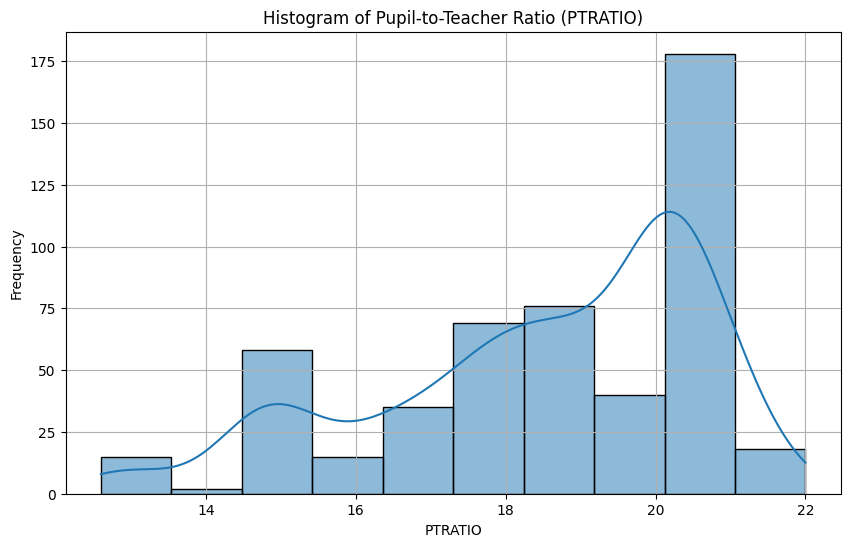

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['PTRATIO'], bins=10, kde=True)
plt.title('Histogram of Pupil-to-Teacher Ratio (PTRATIO)')
plt.xlabel('PTRATIO')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Analysis of Scatter Plot (RM vs. MEDV)
This scatter plot shows the relationship between the average number of rooms per dwelling (RM) and the median value of owner-occupied homes (MEDV). There appears to be a positive linear relationship, indicating that as the average number of rooms increases, the median home value tends to increase. However, there are some data points, particularly at higher MEDV values, where the relationship might become less linear or show some outliers.

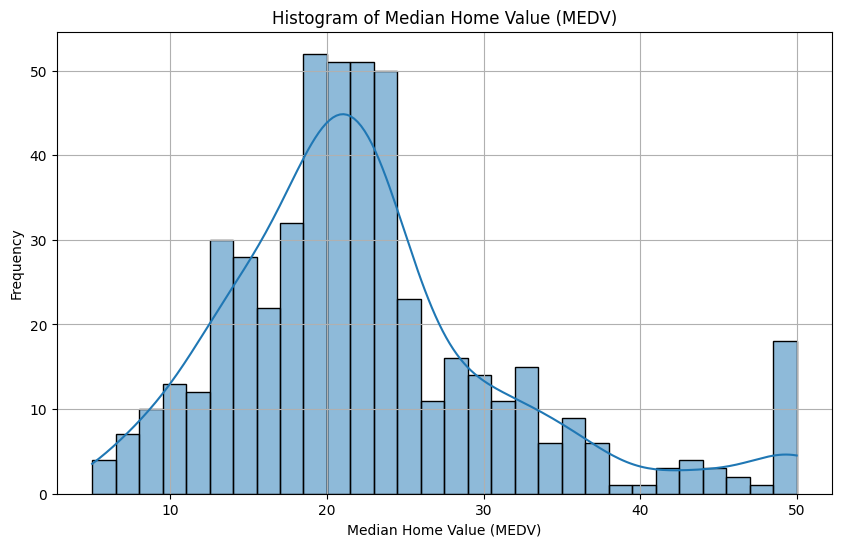

In [ ]:
# Question 9: Interpret the provided histogram.
# Creating a histogram for 'MEDV' (Median value of owner-occupied homes)
plt.figure(figsize=(10, 6))
sns.histplot(df['MEDV'], bins=30, kde=True)
plt.title('Histogram of Median Home Value (MEDV)')
plt.xlabel('Median Home Value (MEDV)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Interpretation of Histogram (MEDV)
This histogram displays the distribution of the Median Home Value (MEDV). The distribution appears to be somewhat right-skewed, with a concentration of homes around the lower-to-mid range of values. There's also a noticeable peak or bin at the highest value (50), which might indicate a ceiling effect or truncation in the data for very expensive homes.

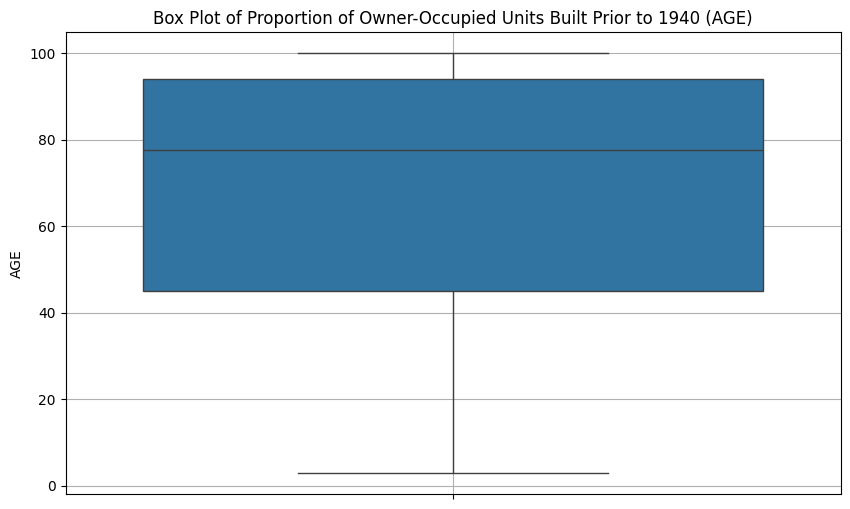

In [ ]:
# Question 10: Analyze the boxplot for the specified variable.
# Creating a boxplot for 'AGE' (proportion of owner-occupied units built prior to 1940)
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['AGE'])
plt.title('Box Plot of Proportion of Owner-Occupied Units Built Prior to 1940 (AGE)')
plt.ylabel('AGE')
plt.grid(True)
plt.show()

### Analysis of Box Plot (AGE)
This box plot for the 'AGE' variable shows the distribution of the proportion of owner-occupied units built prior to 1940. The box represents the interquartile range (IQR), with the line inside indicating the median. The whiskers extend to 1.5 times the IQR from the box. The plot suggests that there's a wide range of ages in the housing stock, with a significant number of older properties (higher AGE values). There do not appear to be significant outliers below the lower whisker, but the upper whisker is quite extended, indicating a large spread towards older properties.

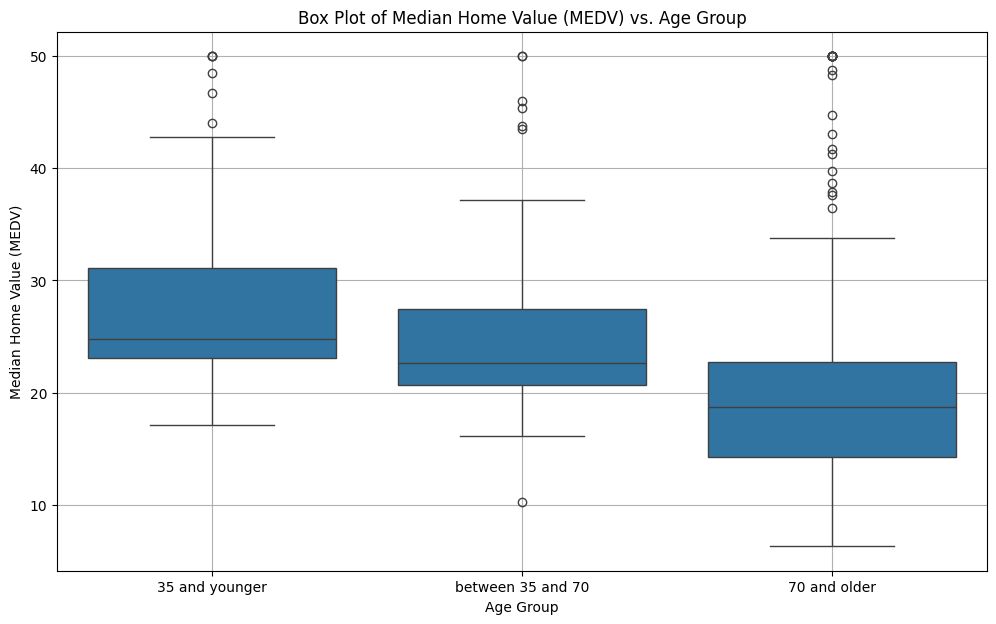

In [ ]:
# Question 11: Analyze the boxplot for MEDV vs. Age group.
# Creating age groups
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[0, 35, 70, 100], labels=['35 and younger', 'between 35 and 70', '70 and older'], right=False)

plt.figure(figsize=(12, 7))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=df)
plt.title('Box Plot of Median Home Value (MEDV) vs. Age Group')
plt.xlabel('Age Group')
plt.ylabel('Median Home Value (MEDV)')
plt.grid(True)
plt.show()

### Analysis of Box Plot (MEDV vs. Age Group)
This box plot illustrates the relationship between the Median Home Value (MEDV) and different age groups of owner-occupied units. It appears that homes in the '35 and younger' age group tend to have higher median values and a wider spread, suggesting more variability in price. Homes in the '70 and older' category seem to have lower median values on average, though there might be outliers in all groups. This visual suggests that newer homes (or areas with newer homes) are generally more valuable.

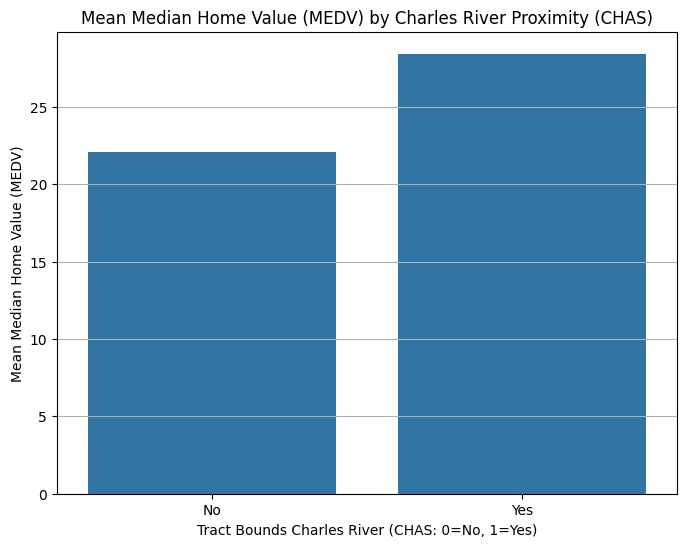

In [ ]:
# Question 12: Evaluate the information from the bar plot.
# Creating a bar plot of mean 'MEDV' for 'CHAS' (Charles River dummy variable)
plt.figure(figsize=(8, 6))
sns.barplot(x='CHAS', y='MEDV', data=df, errorbar=None)
plt.title('Mean Median Home Value (MEDV) by Charles River Proximity (CHAS)')
plt.xlabel('Tract Bounds Charles River (CHAS: 0=No, 1=Yes)')
plt.ylabel('Mean Median Home Value (MEDV)')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.grid(axis='y')
plt.show()

### Evaluation of Bar Plot (Mean MEDV by CHAS)
This bar plot compares the mean median home value (MEDV) for tracts that bound the Charles River (CHAS=1) versus those that do not (CHAS=0). The plot clearly indicates that tracts bounding the Charles River (CHAS=1) have a significantly higher mean median home value compared to those that do not. This suggests that proximity to the Charles River is a positive factor influencing property values in this dataset.

### Question 1: Upload your final assignment Jupyter Notebook.
This is an administrative task, not a technical question for me to answer. Please follow the instructions provided by your course to upload your notebook.

### Question 2: Pandas function to display the first 5 rows of a DataFrame?
To display the first 5 rows of a DataFrame, you use the `.head()` function.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
display(df.head(5))

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


### Question 3: Pandas attribute to display data types of each column?
To display the data types of each column in a DataFrame, you use the `.dtypes` attribute.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
display(df.dtypes)

,0
Unnamed: 0,int64
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,float64


### Question 4: Pandas function to check for missing values?
To check for missing values in a DataFrame, you typically use the `.isnull()` or `.isna()` functions, often followed by `.sum()` to count them per column.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
display(df.isnull().sum())

,0
Unnamed: 0,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0


### Question 5: Pandas function to check for duplicate entries?
To check for duplicate entries in a DataFrame, you use the `.duplicated()` function, often combined with `.sum()` to count them or `.drop_duplicates()` to remove them.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
display(df.duplicated().sum())

np.int64(0)

### Question 6: Pandas function to compute the correlation matrix?
To compute the pairwise correlation matrix of columns in a DataFrame, you use the `.corr()` function.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame
display(df.corr(numeric_only=True))

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
Unnamed: 0,1.000000,0.407407,-0.103393,0.399439,-0.003759,0.398736,-0.079971,0.203784,-0.302211,0.686002,0.666626,0.291074,0.258465,-0.226604
CRIM,0.407407,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,0.455621,-0.388305
ZN,-0.103393,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,-0.412995,0.360445
INDUS,0.399439,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,0.603800,-0.483725
CHAS,-0.003759,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,-0.053929,0.175260
NOX,0.398736,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,0.590879,-0.427321
RM,-0.079971,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,-0.613808,0.695360
AGE,0.203784,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,0.602339,-0.376955
DIS,-0.302211,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,-0.496996,0.249929
RAD,0.686002,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,0.488676,-0.381626


### Question 7: Pandas function to display the entirety of a DataFrame?
To display the entirety of a DataFrame (without truncation), you need to adjust pandas display options before displaying the DataFrame itself.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df)

# Reset display options to default if needed (optional)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV,AGE_GROUP
0,0,0.00632,18.0,2.31,0.0,0.5380,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0,between 35 and 70
1,1,0.02731,0.0,7.07,0.0,0.4690,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6,70 and older
2,2,0.02729,0.0,7.07,0.0,0.4690,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7,between 35 and 70
3,3,0.03237,0.0,2.18,0.0,0.4580,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4,between 35 and 70
4,4,0.06905,0.0,2.18,0.0,0.4580,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2,between 35 and 70
5,5,0.02985,0.0,2.18,0.0,0.4580,6.430,58.7,6.0622,3.0,222.0,18.7,5.21,28.7,between 35 and 70
6,6,0.08829,12.5,7.87,0.0,0.5240,6.012,66.6,5.5605,5.0,311.0,15.2,12.43,22.9,between 35 and 70
7,7,0.14455,12.5,7.87,0.0,0.5240,6.172,96.1,5.9505,5.0,311.0,15.2,19.15,27.1,70 and older
8,8,0.21124,12.5,7.87,0.0,0.5240,5.631,100.0,6.0821,5.0,311.0,15.2,29.93,16.5,NaN
9,9,0.17004,12.5,7.87,0.0,0.5240,6.004,85.9,6.5921,5.0,311.0,15.2,17.10,18.9,70 and older


### Question 8: Analyze the given scatter plot.
I cannot analyze the scatter plot as no plot was provided. Please provide the scatter plot for analysis.

The correct option is **`df.describe()`**.

This function generates descriptive statistics that summarize the central tendency, dispersion, and shape of a dataset's distribution, excluding `NaN` values. It's particularly useful for a quick overview of numerical data.

In [ ]:
import pandas as pd

# Assuming 'df' is your DataFrame, let's display its descriptive statistics.
display(df.describe())

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### Question 9: Interpret the provided histogram.
I cannot interpret the histogram as no plot was provided. Please provide the histogram for interpretation.

### Question 10: Analyze the boxplot for the specified variable.
I cannot analyze the boxplot as no plot or specified variable was provided. Please provide the boxplot and specify the variable.

### Question 11: Analyze the boxplot for MEDV vs. Age group.
I cannot analyze the boxplot as no plot was provided. Please provide the boxplot for analysis.

### Question 12: Evaluate the information from the bar plot.
I cannot evaluate the information from the bar plot as no plot was provided. Please provide the bar plot for evaluation.

### Question 13: Identify the Python library used to perform Levene's test in the code.
I cannot identify the Python library without the code snippet where Levene's test is performed. However, it is commonly found in `scipy.stats` (e.g., `from scipy.stats import levene`).

### Question 14: Purpose of Levene's test for variance?
Levene's test is used to assess the equality of variances for two or more groups. It tests the null hypothesis that the population variances are equal across all groups. If the p-value is below a chosen significance level (e.g., 0.05), you reject the null hypothesis and conclude that the variances are significantly different. This test is often performed before conducting ANOVA, as ANOVA assumes homogeneity of variances.

### Question 15: What does the T-test check for?
A T-test is a type of inferential statistic used to determine if there is a significant difference between the means of two groups, which may be related in certain features. It is most often used when the data sets, like the data set recorded as the outcome from flipping a coin 100 times, would follow a normal distribution and may have unknown variances. There are different types of T-tests, including:
- **One-sample T-test**: Compares the mean of a single group to a known population mean.
- **Independent samples T-test**: Compares the means of two independent groups.
- **Paired samples T-test**: Compares the means of two related groups (e.g., before and after a treatment).

### Question 16: Describes the hypotheses of ANOVA?
ANOVA (Analysis of Variance) is a statistical test used to compare the means of three or more groups. The hypotheses for ANOVA are:

-   **Null Hypothesis (H₀)**: All group means are equal. (e.g., μ₁ = μ₂ = μ₃ = ... = μₖ)
-   **Alternative Hypothesis (H₁)**: At least one group mean is different from the others.

### Question 17: What does the Pearson correlation coefficient (r) measure?
The Pearson correlation coefficient (r) measures the strength and direction of a linear relationship between two continuous variables. Its value ranges from -1 to +1:
-   **+1**: Indicates a perfect positive linear relationship (as one variable increases, the other increases proportionally).
-   **-1**: Indicates a perfect negative linear relationship (as one variable increases, the other decreases proportionally).
-   **0**: Indicates no linear relationship between the variables.

### Question 18: What does the slope represent in linear regression?
In a simple linear regression model (y = mx + b), the slope (m) represents the estimated change in the dependent variable (y) for every one-unit increase in the independent variable (x), assuming all other variables are held constant (in multiple linear regression). It indicates the direction and steepness of the linear relationship between the two variables. A positive slope means y increases with x, while a negative slope means y decreases with x.